In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from fix_bounds import fix_bounds

In [2]:
coarsePath= '/glade/work/adac/microHH/coarseData/'
# Use finer coarse-grained data, interpolated onto LES grid, b/c
# coarse-grained data don't contain z < 2*dz from filteirng
coarse_finest = nc.Dataset(coarsePath+'coarse4x1539_Re2700.nc', 'r')

In [3]:
kmax = 64
zsize = 18.074844397670482
dz = zsize / kmax
z = np.linspace(0.5*dz, zsize-0.5*dz, kmax)
# print(z)
# z_coarse=np.array(coarse_finest.variables["z"])
# #z_coarse=np.array(coarse.variables["z"])
# print(z_coarse)
zstart=0
zend=int(3*kmax/4)

save=True

In [4]:
itimeInit = 0
u_interp,z_interp = fix_bounds('u',coarse_finest,itimeInit,noslip=True,fix_bad_pad=True)
v_interp,_ = fix_bounds('v',coarse_finest,itimeInit,noslip=True,fix_bad_pad=False)
b_interp,_ = fix_bounds('b',coarse_finest,itimeInit,fix_bad_pad=False)

In [5]:
itimeFinal = 2
ul_interp,_ = fix_bounds('u',coarse_finest,itimeFinal,noslip=True,fix_bad_pad=True)
vl_interp,_ = fix_bounds('v',coarse_finest,itimeFinal,noslip=True,fix_bad_pad=False)
bl_interp,_ = fix_bounds('b',coarse_finest,itimeFinal,fix_bad_pad=False)

In [6]:
u = np.interp(z,z_interp,u_interp)
v = np.interp(z,z_interp,v_interp)
b = np.interp(z,z_interp,b_interp)
ul = np.interp(z,z_interp,ul_interp)
vl = np.interp(z,z_interp,vl_interp)
bl = np.interp(z,z_interp,bl_interp)
ug = np.zeros(kmax)
vg = np.zeros(kmax)
ug[:] = 0.073942545263197
vg[:] = 0.

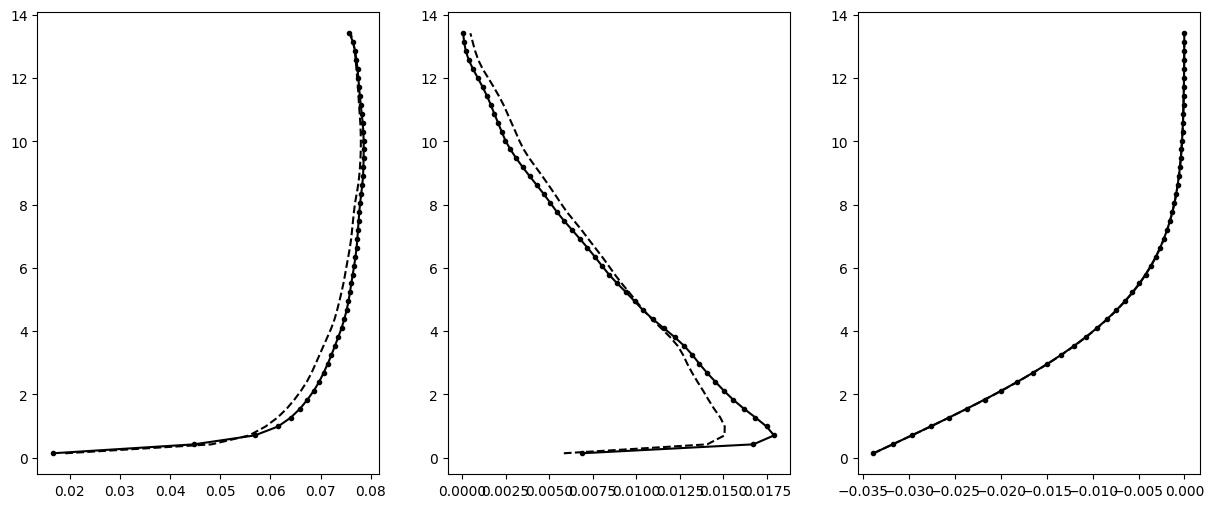

In [7]:
# del(fig,ax)
fig,ax = plt.subplots(1,3,figsize = (15,6))

# ax[0].plot(ug[zstart:zend],z[zstart:zend],'--',color='k',label=r'$u_g$')
ax[0].plot(u[zstart:zend],z[zstart:zend],'k--',label='All 0.0 h')
ax[0].plot(ul[zstart:zend],z[zstart:zend],'k.-',label='DNS 0.5 h')

# ax[1].plot(vg[zstart:zend],z[zstart:zend],'--',color='k',label=r'$v_g$')
ax[1].plot(v[zstart:zend],z[zstart:zend],'k--',label='All 0.0 h')
ax[1].plot(vl[zstart:zend],z[zstart:zend],'k.-',label='DNS 0.5 h')

ax[2].plot(b[zstart:zend],z[zstart:zend],'k--',label='All 0.0 h')
ax[2].plot(bl[zstart:zend],z[zstart:zend],'k.-',label='DNS 0.5 h')

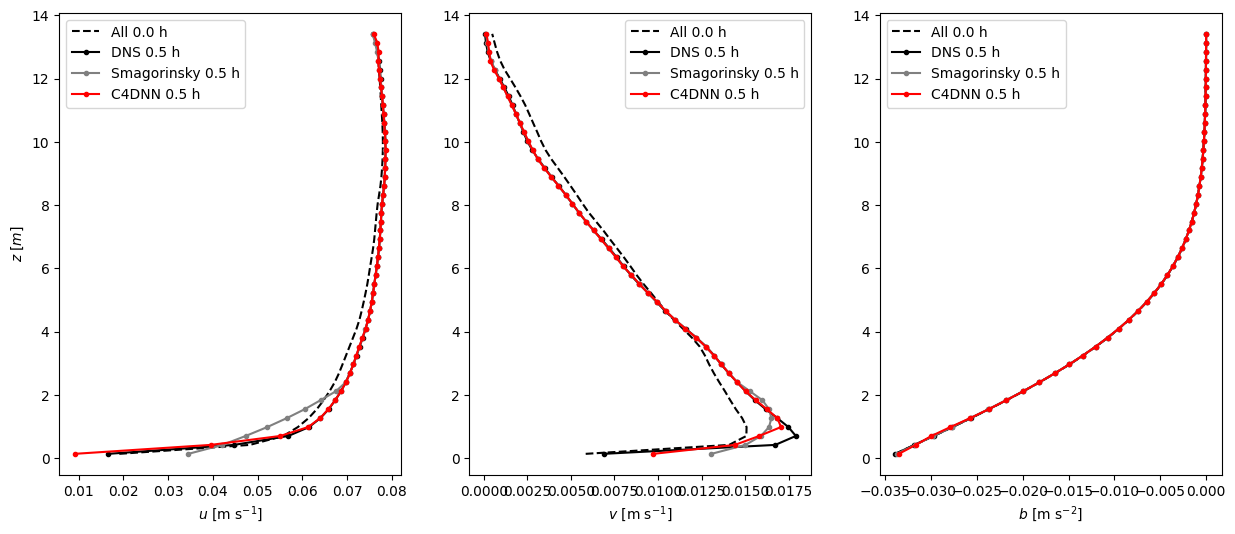

In [8]:
paths=['../cases/SBL_Smag/','../cases/SBL_DNN/']
pathLabels=['Smagorinsky 0.5 h','C4DNN 0.5 h']
colors=['Grey','Red','Blue']
varStrings=['u','v','b']
varLabelStrings=[r'$u$ [m s$^{-1}$]',r'$v$ [m s$^{-1}$]',r'$b$ [m s$^{-2}$]']
itimes=[1,1]

for ifile in range(len(paths)): #tdqm notebook just draws progress bar
    file=paths[ifile]+'SBL2700.default.0000000.nc'
    itime = itimes[ifile]
    
    stats = nc.Dataset(file, 'r')
    default = stats.groups['default']
    thermo = stats.groups['thermo']

    z = stats.variables['z'][:]
        
    for iv,varStr in enumerate(varStrings):

        try:
            var=thermo.variables[varStr][itime, :]
        except:
            var=default.variables[varStr][itime, :]
        # print(stats.variables['time'][itime])

        ax[iv].plot(var[zstart:zend], z[zstart:zend],'.-',color=colors[ifile],label=pathLabels[ifile])
        ax[iv].legend()
        ax[iv].set_xlabel(varLabelStrings[iv])#r'$b [m^2 s^{-2}]$')
    
    ax[0].set_ylabel(r'$z \; [m]$')
        

fig

In [9]:
# save=True
if save:
    plt.figure(fig)
    fmts=["png","eps"]
    for fmt in fmts:
        plt.savefig("Profile_initLastDNS."+fmt, format=fmt)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
